In [1]:
path = 'C:\\Users\\espen\\Documents\\work\\PhD\\papers\\ICIP_salmon_reid\\data\\reid\\'#analysis7'
base = 'C:\\Users\\espen\\Documents\\work\\PhD\\papers\\ICIP_salmon_reid\\code\\'
import os
import sys
sys.path.append(base)
sys.path.append(os.path.join(base, 'helpers'))
from helpers.augmentation_helpers import load_patches
from helpers.training_helpers import excel_match_file_to_traj_IDs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

c:\Users\espen\miniconda3\envs\salmon_reid\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# data_root = Path('C:\\Users\\espen\\Documents\\work\\PhD\\papers\\salmon_re_identification\\data\\reid')
# query_folder = 'analysis15'
# gallery_folder = 'analysis16'
# match_excel_path = data_root / 'a15_a16_idmatch.xlsx'
# output_excel_path = data_root / 'a15_a16_idmatch_with_traj_IDs.xlsx'
# excel_match_file_to_traj_IDs(data_root, query_folder, gallery_folder, match_excel_path, output_excel_path)

In [ ]:
query_files, query_ids = get_file_names_and_labels(config['data_root'], ['analysis15'])
gallery_files, gallery_ids = get_file_names_and_labels(config['data_root'], ['analysis16'])
match_files_and_ids = {'query_files': query_files, 'query_ids': query_ids, 'gallery_files': gallery_files, 'gallery_ids': gallery_ids}

In [6]:
l = 0
num_imgs = 0
for folder in os.listdir(path):
    cl = list(set([cl.split('_')[2] for cl in os.listdir(os.path.join(path, folder, 'labels'))]))
    #if folder != 'analysis15' and folder != 'analysis16':
    if folder == 'analysis15':
        l+=len(cl)
        num_imgs += len(os.listdir(os.path.join(path, folder, 'images')))
print(l)
print(num_imgs)

84
1289


In [3]:
# import cv2
# diags = []
# area = []
# for folder in os.listdir('C:\\Users\\espen\\Documents\\work\\PhD\\papers\\ICIP_salmon_reid\\data\\segmentation\\annotated_salmon_patches'):
#     for img_name in os.listdir(os.path.join('C:\\Users\\espen\\Documents\\work\\PhD\\papers\\ICIP_salmon_reid\\data\\segmentation\\annotated_salmon_patches', folder)):
#         if img_name.endswith('.png'):
#             img = cv2.imread(os.path.join('C:\\Users\\espen\\Documents\\work\\PhD\\papers\\ICIP_salmon_reid\\data\\segmentation\\annotated_salmon_patches', folder, img_name))
#             diag = np.sqrt(img.shape[0]**2 + img.shape[1]**2)
#             area.append(img.shape[0]*img.shape[1])
#             diags.append(diag)
#             #print('Diag: ' + str(diag))
#             #print('Area: ' + str(img.shape[0]*img.shape[1]))
#             if diag < 300:
#                 print(img_name)

In [4]:
# plt.hist(diags, bins=50)
# print(min(diags))

In [5]:
label_files = os.listdir(path + '\\labels') 
# print(label_files)

In [6]:
styling = {
          "parents": {"Q1": {"color": (0,176,80), "thickness": 4}, "Q2": {"color": (146,208,80), "thickness": 4}},
          "slices":  {"Q1_s0": {"color": (0,0,0), "thickness": 1}, "Q1_s1": {"color": (0,0,0), "thickness": 1}, "Q1_s2": {"color": (0,0,0), "thickness": 1}, "Q2_s0": {"color": (0,0,0), "thickness": 1}, "Q2_s1": {"color": (0,0,0), "thickness": 1}, "Q2_s2": {"color": (0,0,0), "thickness": 1}},
          "boxes": {"head": {"color": (0,0,255), "thickness": 4}, "dorsal_fin": {"color": (255,0,0), "thickness": 4}, "tail_fin": {"color": (255,165,0), "thickness": 4}, "adi_fin": {"color": (128,0,128), "thickness": 4}},
        }

# patches = load_patches(
#     Path(path + '\\labels\\' + 'a15_salmon_1295_frame_15740.txt'),
#     valid_threshs={'Q1': 0.25, 'Q2': 0.25},
#     difficulty='easiest',
#     imgs_to_load=['Q1', 'Q1_s0', 'Q1_s1', 'Q1_s2', 'Q2', 'Q2_s0', 'Q2_s1', 'Q2_s2', 'head', 'dorsal_fin', 'complete_img_contours'],
#     crop_slices_to_mask=False,
#     slice_split_idces=[0.3, 0.7],
#     contour_config=styling,
#     bp_margin={'head': 20, 'dorsal_fin': 20, 'tail_fin': 20, 'adi_fin': 10}
# )

In [7]:
# print(patches.keys())
# fig, ax = plt.subplots(figsize=(20,10))
# plt.imshow(patches['complete_img_contours']['img'])
# plt.xticks([])
# plt.yticks([])


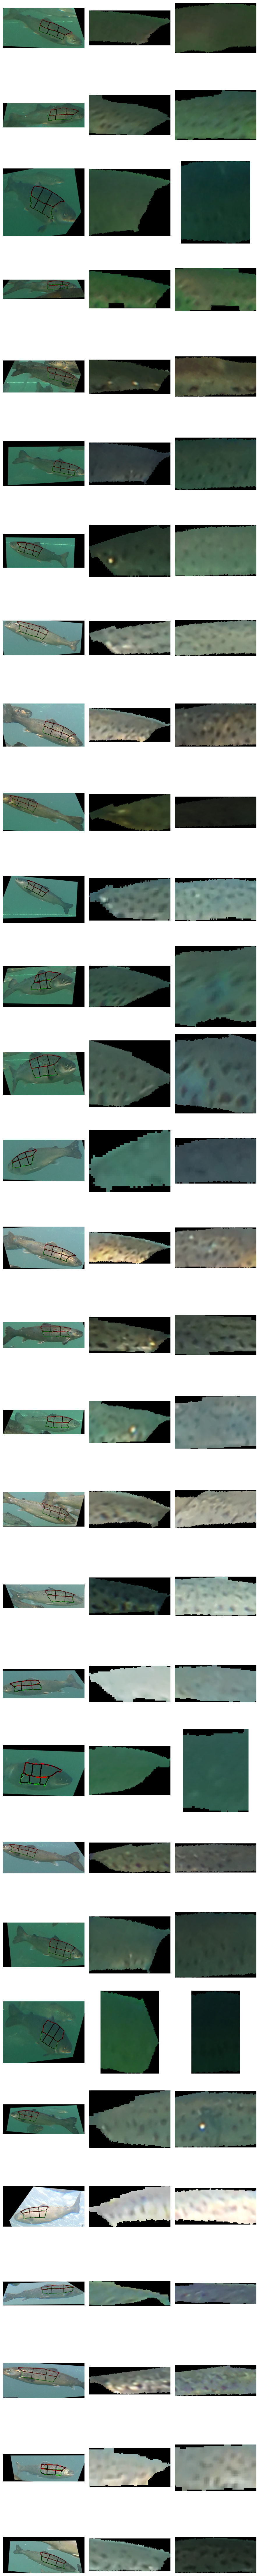

In [8]:
np.random.seed(44)
# Select k x n random files, and display Q1 patch. Set k = 10, n = 5
styling = {
          "parents": {"Q1": {"color": (255,0,0), "thickness": 4}, "Q2": {"color": (0,255,0), "thickness": 4}},
          "slices":  {"Q1_s0": {"color": (0,0,0), "thickness": 2}, "Q1_s1": {"color": (0,0,0), "thickness": 2}, "Q1_s2": {"color": (0,0,0), "thickness": 2}, "Q2_s0": {"color": (0,0,0), "thickness": 2}, "Q2_s1": {"color": (0,0,0), "thickness": 2}, "Q2_s2": {"color": (0,0,0), "thickness": 2}},
        }
n = 30
fig, axs = plt.subplots(n, 3, figsize=(9, 3*n))
for i in range(n):
    rand_idx = np.random.randint(0, len(label_files))
    rand_file = label_files[rand_idx]
    patches = load_patches(
        Path(path + '\\labels\\' + rand_file),
        difficulty='hard',
        imgs_to_load=['Q1', 'Q2', 'Q1_s0', 'Q1_s1', 'Q1_s2', 'Q2_s0', 'Q2_s1', 'Q2_s2', 'complete_img_contours'],
        contour_config = styling,
        
    )
    if patches['complete_img_contours']['img'] is None or patches['complete_img_contours']['img'].shape[0]* patches['complete_img_contours']['img'].shape[1] == 0:
        continue  # Skip too large images
    axs[i, 0].imshow(patches['complete_img_contours']['img'])
    axs[i, 0].axis('off')
    axs[i, 1].imshow(patches['Q1_s2']['img'])
    axs[i, 1].axis('off')
    axs[i, 2].imshow(patches['Q1_s1']['img'])
    
    axs[i, 2].axis('off')
plt.tight_layout()
plt.show()